In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
path = '../../Data' 
files = [f for f in os.listdir(path) if f.endswith('.csv')]

# Khởi tạo dictionary để chứa các bản copy đã sạch (hoặc chuẩn bị làm sạch)
data_cleansed = {}

for file in files:
    # 1. Tách tên file để làm key (vd: 'sales_data.csv' -> 'sales_data')
    file_name = os.path.splitext(file)[0]
    full_path = os.path.join(path, file)
    
    # 2. Đọc file gốc
    df_temp = pd.read_csv(full_path)
    
    # 3. Tạo bản copy và lưu vào dictionary với định dạng key là df_<name>
    # Sử dụng .copy() để đảm bảo đây là một bản sao độc lập hoàn toàn
    dict_key = f"df_{file_name}"
    data_cleansed[dict_key] = df_temp.copy()
    
    print(f"Đã lưu bản copy vào dictionary: data_cleansed['{dict_key}']")

# Ví dụ cách truy cập sau khi load:
# print(data_cleansed['df_ten_file_cua_ban'].head())

Đã lưu bản copy vào dictionary: data_cleansed['df_customers']
Đã lưu bản copy vào dictionary: data_cleansed['df_geography']
Đã lưu bản copy vào dictionary: data_cleansed['df_inventory']
Đã lưu bản copy vào dictionary: data_cleansed['df_orders']


C:\Users\ACER\AppData\Local\Temp\ipykernel_53252\1533433001.py:13: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(full_path)


Đã lưu bản copy vào dictionary: data_cleansed['df_order_items']
Đã lưu bản copy vào dictionary: data_cleansed['df_payments']
Đã lưu bản copy vào dictionary: data_cleansed['df_products']
Đã lưu bản copy vào dictionary: data_cleansed['df_promotions']
Đã lưu bản copy vào dictionary: data_cleansed['df_returns']
Đã lưu bản copy vào dictionary: data_cleansed['df_reviews']
Đã lưu bản copy vào dictionary: data_cleansed['df_sales']
Đã lưu bản copy vào dictionary: data_cleansed['df_sample_submission']
Đã lưu bản copy vào dictionary: data_cleansed['df_shipments']
Đã lưu bản copy vào dictionary: data_cleansed['df_web_traffic']


**PROMOTIONS

In [4]:
# Lấy các bảng ra từ dictionary
df_items = data_cleansed['df_order_items']
df_promo = data_cleansed['df_promotions']
df_prod = data_cleansed['df_products']
# Bước 1: Kết nối đơn hàng với sản phẩm để lấy Category và Price gốc
df_merged = df_items.merge(df_prod[['product_id', 'category', 'price', 'product_name']], 
                           on='product_id', how='left')

# Bước 2: Kết nối với bảng Promotions để lấy thông tin chiến dịch
# Lưu ý: Ta merge cho promo_id chính, bạn có thể làm tương tự cho promo_id_2 nếu muốn
df_merged = df_merged.merge(df_promo, left_on='promo_id', right_on='promo_id', how='left')
df_merged = df_merged.merge(df_promo, left_on='promo_id_2', right_on='promo_id', how='left', suffixes=('', '_p2'))

# Bước 3: Tính toán các chỉ số bổ trợ
df_merged['revenue_actual'] = df_merged['quantity'] * df_merged['unit_price']
df_merged['revenue_before_discount'] = df_merged['quantity'] * df_merged['price']
df_merged['is_promo'] = (df_merged['promo_id'].notna()|df_merged['promo_id_2'].notna()).map({True: 'Có KM', False: 'Không KM'})

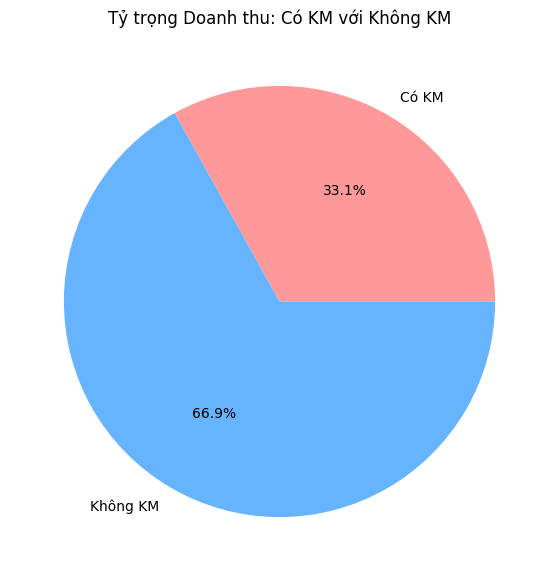

In [5]:
plt.figure(figsize=(7, 7))
revenue_by_promo = df_merged.groupby('is_promo')['revenue_actual'].sum()
plt.pie(revenue_by_promo, labels=revenue_by_promo.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff'])
plt.title('Tỷ trọng Doanh thu: Có KM với Không KM')
plt.show()

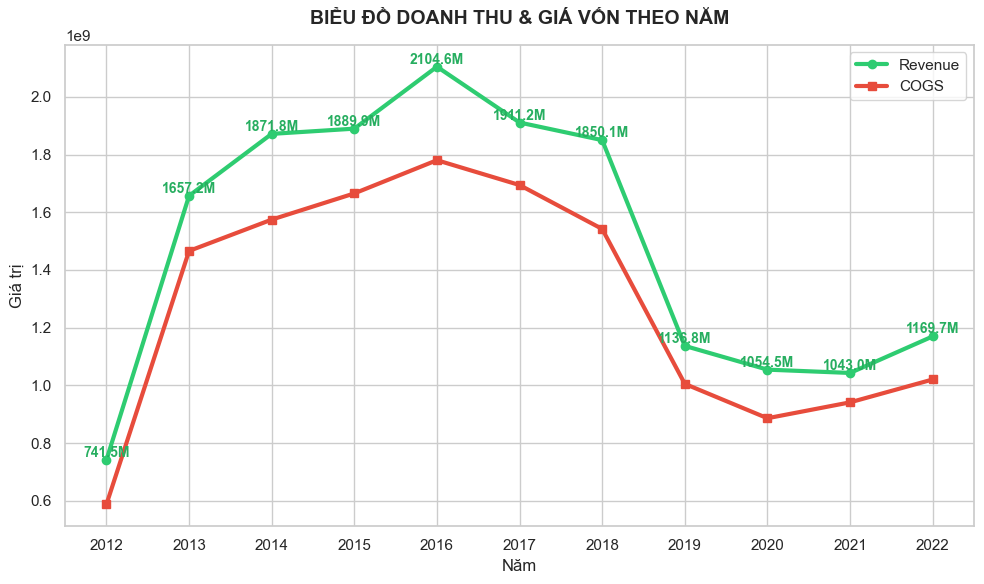

In [6]:
df_sales = data_cleansed['df_sales']
df_sales['Date'] = pd.to_datetime(df_sales['Date'])

# Tạo cột Year và tính tổng theo năm
df_yearly = df_sales.groupby(df_sales['Date'].dt.year).agg({
    'Revenue': 'sum',
    'COGS': 'sum'
}).reset_index()

# 2. Vẽ biểu đồ
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Vẽ đường Revenue & COGS theo Năm
plt.plot(df_yearly['Date'], df_yearly['Revenue'], marker='o', label='Revenue', color='#2ecc71', linewidth=3)
plt.plot(df_yearly['Date'], df_yearly['COGS'], marker='s', label='COGS', color='#e74c3c', linewidth=3)

# 3. Trang trí
plt.title('BIỂU ĐỒ DOANH THU & GIÁ VỐN THEO NĂM', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Năm', fontsize=12)
plt.ylabel('Giá trị', fontsize=12)

# Hiển thị số liệu (Data Labels) theo đơn vị tỷ (hoặc triệu tùy ông)
for i in range(len(df_yearly)):
    plt.text(df_yearly['Date'][i], df_yearly['Revenue'][i], f"{df_yearly['Revenue'][i]/1e6:.1f}M", 
             va='bottom', ha='center', fontsize=10, color='#27ae60', fontweight='bold')

# Fix trục X chỉ hiển thị số năm nguyên (2012, 2013...)
plt.xticks(df_yearly['Date'].astype(int)) 

plt.legend()
plt.tight_layout()
plt.show()

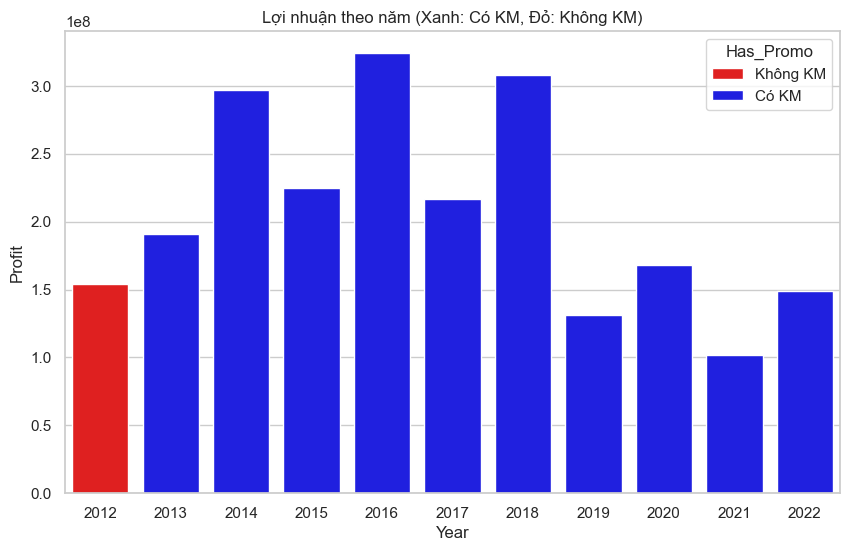

In [7]:
# 1. Chuẩn bị dữ liệu
df_sales = data_cleansed['df_sales']
df_promo = data_cleansed['df_promotions']

df_sales['Date'] = pd.to_datetime(df_sales['Date'])
df_promo['start_date'] = pd.to_datetime(df_promo['start_date'])
df_promo['end_date'] = pd.to_datetime(df_promo['end_date'])

# 2. Xác định các năm có KM
years_with_promo = set()
for _, row in df_promo.iterrows():
    s_yr = row['start_date'].year
    e_yr = row['end_date'].year
    for yr in range(s_yr, e_yr + 1):
        years_with_promo.add(yr)

# 3. Tính lợi nhuận theo năm
df_yearly = df_sales.groupby(df_sales['Date'].dt.year).agg({
    'Revenue': 'sum',
    'COGS': 'sum'
}).reset_index()

df_yearly.columns = ['Year', 'Revenue', 'COGS']
df_yearly['Profit'] = df_yearly['Revenue'] - df_yearly['COGS']
df_yearly['Has_Promo'] = df_yearly['Year'].apply(lambda x: 'Có KM' if x in years_with_promo else 'Không KM')

# 4. Vẽ biểu đồ
plt.figure(figsize=(10, 6))
sns.barplot(data=df_yearly, x='Year', y='Profit', hue='Has_Promo', 
            palette={'Có KM': 'blue', 'Không KM': 'red'})

plt.title('Lợi nhuận theo năm (Xanh: Có KM, Đỏ: Không KM)')
plt.show()

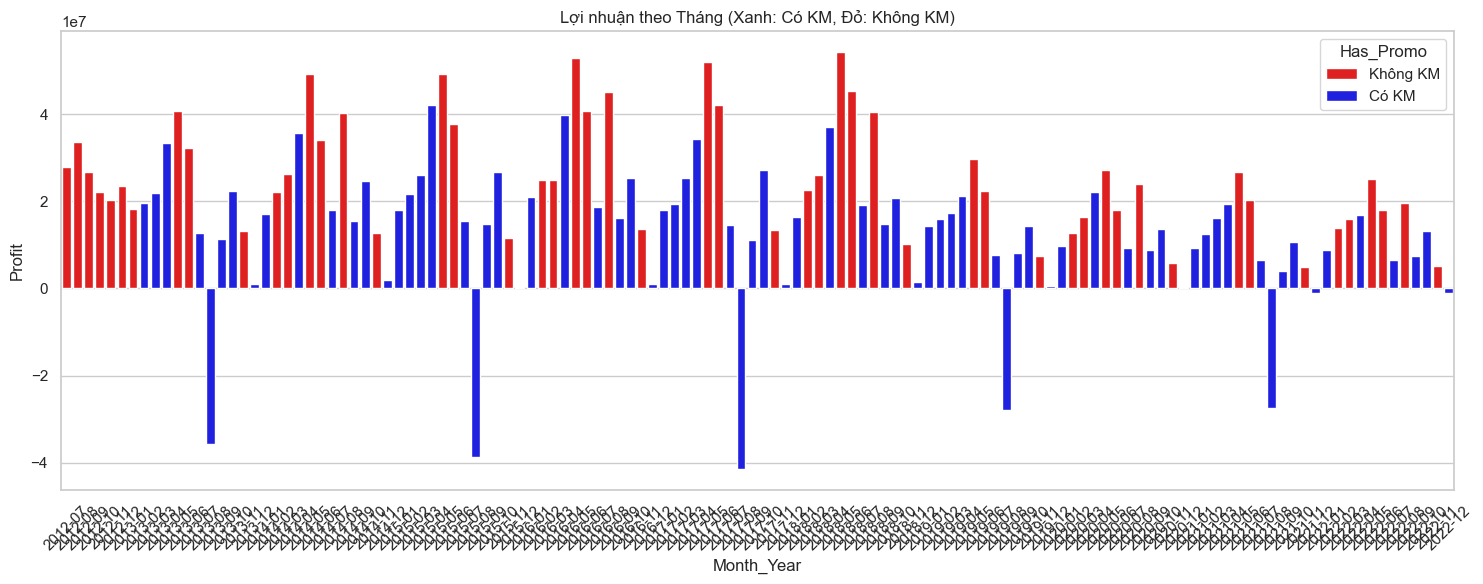

In [9]:
# 1. Chuẩn bị dữ liệu ngày tháng
df_sales['Date'] = pd.to_datetime(df_sales['Date'])
df_promo['start_date'] = pd.to_datetime(df_promo['start_date'])
df_promo['end_date'] = pd.to_datetime(df_promo['end_date'])

# 2. Xác định các THÁNG có khuyến mãi
# Ta dùng định dạng 'YYYY-MM' để lưu trữ các tháng có KM
months_with_promo = set()
for _, row in df_promo.iterrows():
    # Tạo một chuỗi thời gian từ start_date đến end_date
    date_range = pd.date_range(start=row['start_date'], end=row['end_date'], freq='MS') 
    for d in date_range:
        months_with_promo.add(d.strftime('%Y-%m'))
    # Đảm bảo tháng kết thúc cũng được tính (phòng trường hợp end_date không phải đầu tháng)
    months_with_promo.add(row['end_date'].strftime('%Y-%m'))

# 3. Gom nhóm doanh thu theo Tháng
# Tạo cột 'Month_Year' định dạng YYYY-MM để vẽ biểu đồ
df_sales['Month_Year'] = df_sales['Date'].dt.strftime('%Y-%m')

df_monthly = df_sales.groupby('Month_Year').agg({
    'Revenue': 'sum',
    'COGS': 'sum'
}).reset_index()

# 4. Tính lợi nhuận và đánh dấu KM
df_monthly['Profit'] = df_monthly['Revenue'] - df_monthly['COGS']
df_monthly['Has_Promo'] = df_monthly['Month_Year'].apply(lambda x: 'Có KM' if x in months_with_promo else 'Không KM')

# 5. Sắp xếp lại theo thời gian để biểu đồ không bị đảo lộn
df_monthly = df_monthly.sort_values('Month_Year')

# 6. Vẽ biểu đồ
plt.figure(figsize=(15, 6))
sns.barplot(data=df_monthly, x='Month_Year', y='Profit', hue='Has_Promo', 
            palette={'Có KM': 'blue', 'Không KM': 'red'}, dodge=False)

plt.xticks(rotation=45) # Xoay tên tháng cho dễ đọc
plt.title('Lợi nhuận theo Tháng (Xanh: Có KM, Đỏ: Không KM)')
plt.tight_layout()
plt.show()

**RETURN

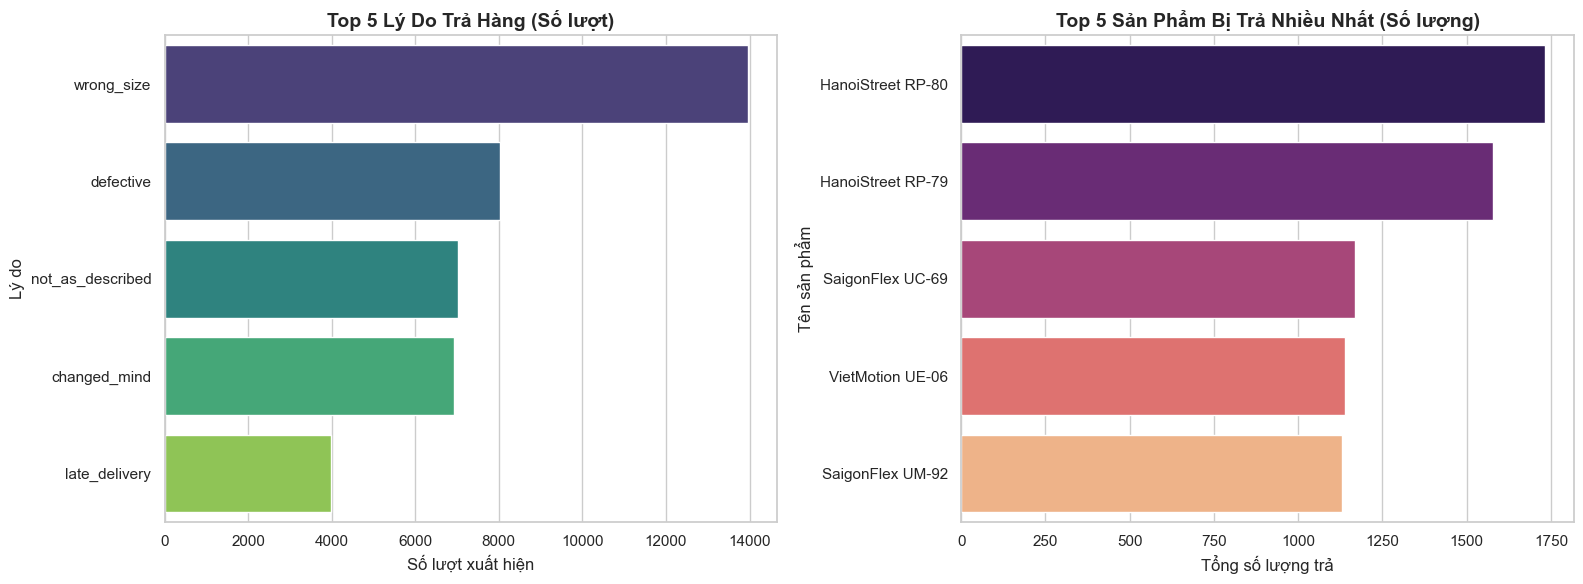

In [10]:
# Thiết lập phong cách cho biểu đồ
sns.set_theme(style="whitegrid")

# 1. Xử lý dữ liệu cho Lý do trả hàng
top_reasons = data_cleansed['df_returns']['return_reason'].value_counts().head(5).reset_index()
top_reasons.columns = ['reason', 'count']

# 2. Xử lý dữ liệu cho Sản phẩm bị trả nhiều nhất
returns_agg = data_cleansed['df_returns'].groupby('product_id')['return_quantity'].sum().reset_index()
top_products = pd.merge(
    returns_agg, 
    data_cleansed['df_products'][['product_id', 'product_name']], 
    on='product_id'
).sort_values(by='return_quantity', ascending=False).head(5)

# TẠO FIG VỚI 2 BIỂU ĐỒ CỘT (SUBPLOTS)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ 1: Top 5 lý do trả hàng
sns.barplot(
    data=top_reasons, 
    x='count', 
    y='reason', 
    hue='reason',      # Gán hue bằng biến y
    ax=axes[0], 
    palette='viridis', 
    legend=False       # Tắt legend để biểu đồ gọn gàng
)
axes[0].set_title('Top 5 Lý Do Trả Hàng (Số lượt)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Số lượt xuất hiện')
axes[0].set_ylabel('Lý do')

# Biểu đồ 2: Top 5 sản phẩm bị trả nhiều nhất
sns.barplot(
    data=top_products, 
    x='return_quantity', 
    y='product_name', 
    hue='product_name', # Gán hue bằng biến y
    ax=axes[1], 
    palette='magma', 
    legend=False        # Tắt legend
)
axes[1].set_title('Top 5 Sản Phẩm Bị Trả Nhiều Nhất (Số lượng)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Tổng số lượng trả')
axes[1].set_ylabel('Tên sản phẩm')

plt.tight_layout()
plt.show()

**CUSTOMER

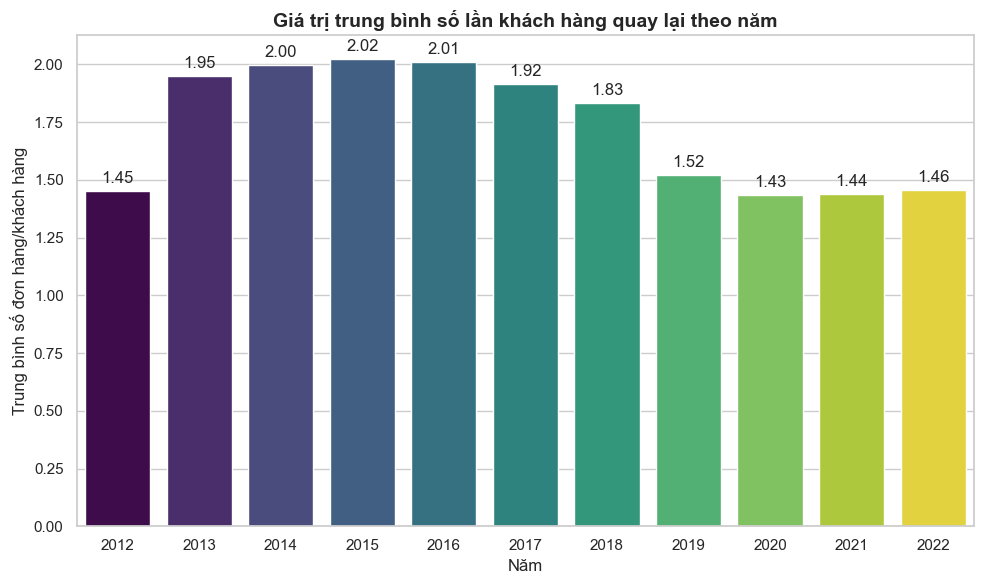

In [15]:
# Lấy dữ liệu từ dictionary
df_orders = data_cleansed['df_orders']

# Bước 1: Đảm bảo order_date là định dạng datetime và trích xuất năm
df_orders['order_date'] = pd.to_datetime(df_orders['order_date'])
df_orders['order_year'] = df_orders['order_date'].dt.year

# Bước 2: Tính số lần đặt hàng của mỗi khách hàng theo từng năm
# (Giả định "khách hàng quay lại" tính trên phạm vi từng năm)
customer_retention = df_orders.groupby(['order_year', 'customer_id']).size().reset_index(name='order_count')

# Bước 3: Tính trung bình số đơn hàng (số lần quay lại) của khách hàng theo năm
yearly_avg = customer_retention.groupby('order_year')['order_count'].mean().reset_index()

# Bước 4: Vẽ biểu đồ cột
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=yearly_avg, 
    x='order_year', 
    y='order_count', 
    hue='order_year', 
    palette='viridis', 
    legend=False
)

# Thêm nhãn giá trị trên đầu mỗi cột cho trực quan
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

plt.title('Giá trị trung bình số lần khách hàng quay lại theo năm', fontsize=14, fontweight='bold')
plt.xlabel('Năm', fontsize=12)
plt.ylabel('Trung bình số đơn hàng/khách hàng', fontsize=12)
plt.tight_layout()
plt.show()